# Reducing a He burning network

We will start with a large network that has everything we need for He burning and then try to reduce it.  Our metric will be an integration of the network, and checking the abundances at several times

In [1]:
import pynucastro as pyna

## Initial network

We'll start with a moderately large network

In [2]:
net = pyna.network_helper(["p", "n", "he4",
                           "c12", "c14",
                           "n13", "n14", 
                           "o16", "o17", "o18",
                           "f18",
                           "ne20", "ne21", "ne22",
                           "na22", "na23",
                           "mg23", "mg24", "mg25", "mg26",
                           "al27",
                           "si27", "si28",
                           "p31",
                           "s31", "s32",
                           "cl35",
                           "ar36",
                           "k39",
                           "ca40",
                           "sc43",
                           "ti44",
                           "v47",
                           "cr48",
                           "mn51",
                           "fe52", "fe53", "fe54", "fe55", "fe56",
                           "co55", "co56", "co57",
                           "ni56", "ni57", "ni58",
                           "cu59",
                           "zn60"], tabular_ordering=["ffn", "oda", "langanke"])

In [3]:
net.summary()

Network summary
---------------
  explicitly carried nuclei: 48
  approximated-out nuclei: 0
  inert nuclei (included in carried): 0

  total number of rates: 279

  rates explicitly connecting nuclei: 279
  hidden rates: 0

  reaclib rates: 130
  starlib rates: 0
  temperature tabular rates: 0
  weak tabular rates: 20
  approximate rates: 0
  derived rates: 129
  modified rates: 0
  custom rates: 0


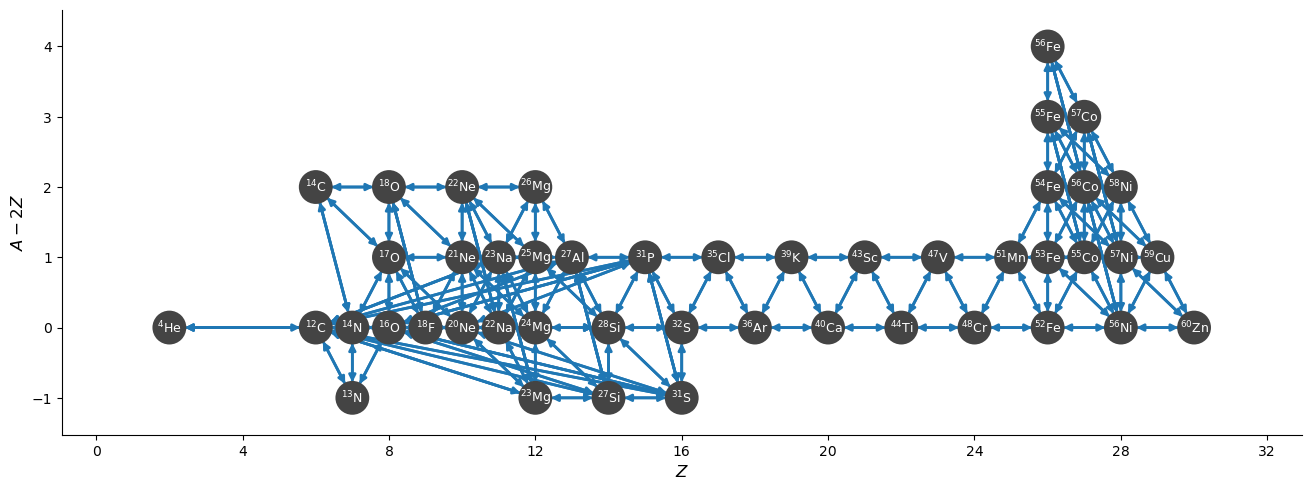

In [4]:
fig = net.plot(rotated=True, hide_xalpha=True, hide_xp=True,
               node_size=500, node_font_size=9, size=(1300, 500))

## Integrate to get reference

We will integrate this initial network to get the reference values for some key nuclei

In [5]:
comp = pyna.Composition(net.unique_nuclei)
comp.X[pyna.Nucleus("he4")] = 0.98
comp.X[pyna.Nucleus("n14")] = 0.01
comp.X[pyna.Nucleus("ne22")] = 0.01
Y0 = comp.get_molar_array()

In [6]:
rho = 1.e5
T = 2.e9

In [7]:
tmax = 3.e4

In [8]:
sol = net.integrate_network(tmax, rho, T, Y0, screen_method="chugunov_2007", atol=1.e-10)

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N14 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C14 partition function is not supported by tables: set log_pf = 0.0 b

### Visualize the reference integration

/home/zingale/development/pynucastro/pynucastro/networks/python_network.py:379: UserWarning: Attempt to set non-positive xlim on a log-scaled axis will be ignored.
  ax.set_xlim(tmin, tmax)


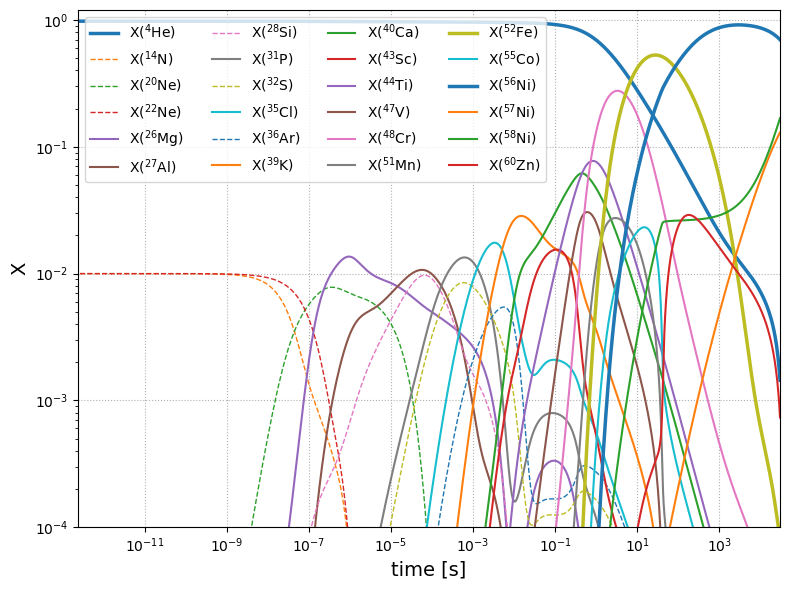

In [9]:
fig = sol.plot_evolution(X_cutoff_value=5.e-3, ymin=1.e-4, three_level_style=True)

### Capture some reference values

We will use some reference values for the error estimation

In [11]:
references = {}

early evolution

In [15]:
t_ref = 1.e-7
enuc_ref = sol.energy_release_at(t_ref)

Xs = sol.X_at(t_ref)
comp = pyna.Composition(sol.unique_nuclei)
comp.set_array(Xs)

X_ref = []
X_ref.append(("he4", comp.X[pyna.Nucleus("he4")]))
X_ref.append(("n14", comp.X[pyna.Nucleus("n14")]))
X_ref.append(("ne20", comp.X[pyna.Nucleus("ne20")]))
X_ref.append(("ne22", comp.X[pyna.Nucleus("ne22")]))

references[t_ref] = (enuc_ref, X_ref)

final evolution

In [16]:
t_ref = tmax
enuc_reference = sol.energy_release_at(t_ref)

Xs = sol.X_at(t_ref)
comp = pyna.Composition(sol.unique_nuclei)
comp.set_array(Xs)

X_reference = []
X_reference.append(("ni56", comp.X[pyna.Nucleus("ni56")]))
X_reference.append(("ni57", comp.X[pyna.Nucleus("ni57")]))
X_reference.append(("ni58", comp.X[pyna.Nucleus("ni58")]))
X_reference.append(("zn60", comp.X[pyna.Nucleus("zn60")]))
X_reference.append(("he4", comp.X[pyna.Nucleus("he4")]))

references[t_ref] = (enuc_ref, X_ref)

## Sensitivity analysis

first we'll define our error function

In [21]:
import math

In [22]:
def err_func(rnet, rho, T, tmax, references):
    # first make the nuclei we definitely want are present
    n_need = ["p", "he4", "c12", "n14", "o16",
              "ne20", "ne22", "mg24", "si28", "s32",
              "ar36", "ca40", "ti44", "cr48",
              "fe52", "fe56", "ni56", "ni58"]
    for n in n_need:
        if pyna.Nucleus(n) not in rnet.unique_nuclei:
            # return an error >> 1 so this will be a failure
            return 1000

    if not rnet.isNSECompatible():
        return 1000
        
    # now integrate
    comp = pyna.Composition(rnet.unique_nuclei)
    comp.X[pyna.Nucleus("he4")] = 0.98
    comp.X[pyna.Nucleus("n14")] = 0.01
    comp.X[pyna.Nucleus("ne22")] = 0.01

    Y0 = comp.get_molar_array()
    sol = rnet.integrate_network(tmax, rho, T, Y0, screen_method="chugunov_2007", atol=1.e-10)

    if not sol.success:
        return 1000

    nuclei = sol.unique_nuclei

    err = -1.e30
    for t_ref in references:
        enuc_ref, X_ref = references[t_ref]
        
        # consider the energy release
        err_ener = (abs(sol.energy_release_at(t_ref) - enuc_ref) /
                    abs(enuc_ref))

        # and the nuclei
        Xs = sol.X_at(t_ref)

        # we want nuclei with small Z to be depleted
        if t_ref > 0.99 * tmax:
            comp.set_array(Xs)
            for n in comp.X:
                if n.Z >= 6 and n.Z <= 12:
                    if comp.X[n] > 1.e-5:
                        return 1000
    
        err_X = 0.0
        for nuc, Xval in X_ref:
            idx = nuclei.index(pyna.Nucleus(nuc))
            err_X += (abs(Xval - Xs[idx]) / Xval)**2
        err_X = math.sqrt(err_X / len(X_ref))

        err = max(err, max(err_ener, err_X))
        
    return err

In [ ]:
reduced_net = pyna.sens_analysis(net, err_func,
                                 thresh=0.1, print_prog=True,
                                 args=(rho, T, tmax, references))

Performing sensitivity analysis...
Pass 1: [⊙⊙⊙⊙                                              ] 8%

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N14 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


Pass 1: [⊙⊙⊙⊙⊙                                             ] 10%

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C14 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N14 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))


Pass 1: [⊙⊙⊙⊙⊙⊙⊙⊙                                          ] 17%

...

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N14 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C14 partition function is not supported by tables: set log_pf = 0.0 b

Pass 1: [⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙                       ] 54%

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N14 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C14 partition function is not supported by tables: set log_pf = 0.0 b

Pass 1: [⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙⊙                     ] 58%

/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C12 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N13 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: N14 partition function is not supported by tables: set log_pf = 0.0 by default
  warnings.warn(UserWarning(f'{nuc} partition function is not supported by tables: set log_pf = 0.0 by default'))
/home/zingale/development/pynucastro/pynucastro/rates/derived_rate.py:120: UserWarning: C14 partition function is not supported by tables: set log_pf = 0.0 b